# Vanilla PINN —— Setting D

**Setting D (审稿意见 2)**:  三离子 + 非均匀通道 + 非零永久电荷

$$\frac{\varepsilon^2}{h(x)}\frac{\mathrm{d}}{\mathrm{d}x}\Big(h(x)\frac{\mathrm{d}\phi}{\mathrm{d}x}\Big)=-\sum_{j=1}^{3}\alpha_j c_j-Q,\qquad
h(x)\frac{\mathrm{d}c_k}{\mathrm{d}x}+\alpha_k c_k h(x)\frac{\mathrm{d}\phi}{\mathrm{d}x}=-J_k$$

| | |
|---|---|
| 离子 | $n=3$, $\alpha=(2,1,-1)$ —— Ca²⁺ : Na⁺ : Cl⁻ |
| 通道几何 | $h(x)=1-0.2\sin(\pi x)\in[0.5,1.5]$, 中部收窄 3:1 |
| 永久电荷 | $Q\equiv -0.15$ |
| 边界条件 | $V=1$, $L=(0.5,1.0,1.5)$, $R=(3,4.5,4)$ |
| 摄动参数 | $\varepsilon=10^{-2}$ |

本算例同时具备**三种以上离子**、**非常数 $h(x)$** 与**非零 $Q$**, 用以检验框架在
Theorem 1 所覆盖的一般情形下的适用性。参考解由 `scipy.integrate.solve_bvp`
经 $\varepsilon$ 延拓求得。


## 1. 导入库和设置


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time, copy
from scipy.integrate import solve_bvp as scipy_bvp, trapezoid

# 自动选择计算设备
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {DEVICE}")

# Matplotlib配置
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16

# 边界层拉伸坐标最大值
XI_MAX = 15.0


使用设备: cuda


## 2. 问题设置 (Setting D)


In [ ]:
N_ION = 3
ALPHA_NP = np.array([2.0, 1.0, -1.0])
VAR_NAMES = ['phi', 'c1', 'c2', 'c3']
VAR_LABELS = ['φ', 'c₁ (Ca²⁺)', 'c₂ (Na⁺)', 'c₃ (Cl⁻)']

eps = 1e-2                       # Debye 长度参数
V = 1.0                          # 施加电压
L = np.array([0.5, 1, 1.5])    # 左浴浓度 (Ca, Na, Cl)
R = np.array([3, 4.5, 4])      # 右浴浓度
Q0 = -0.15                         # 永久电荷密度

H0, H1 = 1, 0.2                # h(x) = H0 - H1·sin(πx)

def h_np(x):    return H0 - H1*np.sin(np.pi*np.asarray(x, dtype=float))
def dh_np(x):   return -H1*np.pi*np.cos(np.pi*np.asarray(x, dtype=float))
def kap_np(x):  return dh_np(x)/h_np(x)

def h_t(x):     return H0 - H1*torch.sin(np.pi*x)
def dh_t(x):    return -H1*np.pi*torch.cos(np.pi*x)
def kap_t(x):   return dh_t(x)/h_t(x)

ALPHA = torch.tensor(ALPHA_NP, dtype=torch.float32, device=DEVICE)
H_AT_0, KAP_AT_0 = float(h_np(0.0)), float(kap_np(0.0))
H_AT_1, KAP_AT_1 = float(h_np(1.0)), float(kap_np(1.0))

_fmt = lambda a: '(' + ', '.join(f'{v:g}' for v in a) + ')'
print(f'  Setting D:  n = {N_ION},  α = {_fmt(ALPHA_NP)}')
print(f"  ε = {eps},  V = {V},  Q = {Q0}")
print(f"  h(0) = {H_AT_0:.3f},  h(0.5) = {h_np(0.5):.3f},  h(1) = {H_AT_1:.3f}")
print(f"  κ(0) = {KAP_AT_0:+.4f},  κ(1) = {KAP_AT_1:+.4f}")
print(f"  左浴 L = {_fmt(L)}   Σα·L + Q = {ALPHA_NP @ L + Q0:+.3f}")
print(f"  右浴 R = {_fmt(R)}   Σα·R + Q = {ALPHA_NP @ R + Q0:+.3f}")
print('  (两端 Σα·bc + Q 均非零, 满足 Theorem 1 的非退化条件 (H3))')


  Setting D:  n = 3,  α = (2, 1, -1)
  ε = 0.01,  V = 1.0,  Q = -0.15
  h(0) = 1.000,  h(0.5) = 0.800,  h(1) = 1.000
  κ(0) = -0.6283,  κ(1) = +0.6283
  左浴 L = (0.5, 1, 1.5)   Σα·L + Q = +0.350
  右浴 R = (3, 4.5, 4)   Σα·R + Q = +6.350
  (两端 Σα·bc + Q 均非零, 满足 Theorem 1 的非退化条件 (H3))


## 3. 网络构建和辅助函数


In [3]:
def make_mlp(in_dim, out_dim, hidden=64, layers=4):
    """构建全连接网络 (SiLU 激活, Xavier 初始化)"""
    seq = [nn.Linear(in_dim, hidden), nn.SiLU()]
    for _ in range(layers - 1):
        seq += [nn.Linear(hidden, hidden), nn.SiLU()]
    seq += [nn.Linear(hidden, out_dim)]
    net = nn.Sequential(*seq)
    for m in net.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight, gain=1.0)
            nn.init.zeros_(m.bias)
    return net


def grad(y, x):
    """自动微分求梯度 dy/dx"""
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]


def softplus_pos(z):
    """浓度的正值约束 σ₊(z) = ln(1+eᶻ) + 0.01"""
    return nn.functional.softplus(z) + 0.01


## 4. Vanilla PINN 模型


In [4]:
class PINN_PNP(nn.Module):
    """
    Vanilla PINN (Setting D):  单一网络 x → (c₁, c₂, c₃, φ)
    """
    def __init__(self, layers=[1, 96, 96, 96, 96, 96, 1 + N_ION]):
        super(PINN_PNP, self).__init__()
        self.linears = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        self.activation = nn.Tanh()

    def forward(self, x):
        u = x
        for lin in self.linears[:-1]:
            u = self.activation(lin(u))
        u = self.linears[-1](u)
        c = [u[:, k:k+1] for k in range(N_ION)]
        phi = u[:, N_ION:N_ION+1]
        return c, phi


## 5. 损失函数


In [5]:
def compute_loss(model, epsilon, V, L, R, device):
    """
    Vanilla PINN / AA-PINN 损失 (Setting D)

      Poisson:  ε²(φ'' + κ(x)φ') + Σⱼαⱼcⱼ + Q = 0
      NP     :  通量 Jₖ = -h(x)(cₖ' + αₖcₖφ') 应为常数, 即 dJₖ/dx = 0
      BC     :  φ(0)=V, cₖ(0)=Lₖ, φ(1)=0, cₖ(1)=Rₖ
    """
    losses = {}
    N_in = 500
    x_in = torch.rand(N_in, 1, device=device, requires_grad=True)
    c_pred, phi_pred = model(x_in)

    dphi = grad(phi_pred, x_in)
    d2phi = grad(dphi, x_in)

    charge = sum(ALPHA[k]*c_pred[k] for k in range(N_ION))
    res_p = epsilon**2*(d2phi + kap_t(x_in)*dphi) + charge + Q0
    losses['p'] = torch.mean(res_p**2)

    hx = h_t(x_in)
    loss_np = 0.0
    for k in range(N_ION):
        dck = grad(c_pred[k], x_in)
        flux_k = hx*(dck + ALPHA[k]*c_pred[k]*dphi)
        loss_np = loss_np + torch.mean(grad(flux_k, x_in)**2)
    losses['np'] = loss_np

    x_l = torch.zeros(1, 1, device=device)
    x_r = torch.ones(1, 1, device=device)
    cL, phiL = model(x_l)
    cR, phiR = model(x_r)
    loss_bc = (phiL - V)**2 + phiR**2
    for k in range(N_ION):
        loss_bc = loss_bc + (cL[k] - L[k])**2 + (cR[k] - R[k])**2
    losses['bc'] = loss_bc.mean()

    total = losses['p'] + losses['np'] + 50.0*losses['bc']
    losses['total'] = total
    return total, {k: (v.item() if torch.is_tensor(v) else v)
                   for k, v in losses.items() if k != 'total'}


def train_single_net(model, epochs, log_interval, tag=''):
    """单网络方法的通用训练循环"""
    params = list(model.parameters())
    opt = torch.optim.Adam(params, lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    best, snap, hist = float('inf'), None, []
    for it in range(epochs):
        opt.zero_grad()
        total, det = compute_loss(model, eps, V, L, R, DEVICE)
        total.backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0)
        opt.step()
        sched.step()
        tv = total.item()
        hist.append(tv)
        if tv < best:
            best, snap = tv, copy.deepcopy(model.state_dict())
        if log_interval and (it + 1) % log_interval == 0:
            msg = '  '.join(f'{k}={v:.3e}' for k, v in det.items())
            print(f'    {tag}[{it+1:>7d}]  total={tv:.4e}   {msg}')
    if snap is not None:
        model.load_state_dict(snap)
    return {'loss': hist, 'best': best}


def predict(model, x_np):
    """单网络方法: 直接前向 + 由解数值反推通量 Jₖ = -h(cₖ' + αₖcₖφ')"""
    x_t = torch.tensor(x_np.reshape(-1, 1), dtype=torch.float32,
                       device=DEVICE, requires_grad=True)
    c_t, phi_t = model(x_t)
    dphi = grad(phi_t, x_t).detach().cpu().numpy().flatten()
    u = {'phi': phi_t.detach().cpu().numpy().flatten()}
    J = np.zeros(N_ION)
    for k in range(N_ION):
        ck = c_t[k].detach().cpu().numpy().flatten()
        dck = grad(c_t[k], x_t).detach().cpu().numpy().flatten()
        u[f'c{k+1}'] = ck
        Jk = -h_np(x_np)*(dck + ALPHA_NP[k]*ck*dphi)
        m = (x_np > 0.2) & (x_np < 0.8)          # 在外区域取平均, 避开边界层
        J[k] = float(np.mean(Jk[m]))
    return u, J


## 6. 训练函数


## 7. 构建模型


In [6]:
METHOD_NAME = 'Vanilla PINN'
LAYERS = [1, 96, 96, 96, 96, 96, 1 + N_ION]
EPOCHS = 300000


def build_model():
    return PINN_PNP(layers=LAYERS).to(DEVICE)


def train_model(model):
    return train_single_net(model, EPOCHS, 300)


_m = build_model()
print(f'{METHOD_NAME}:  层结构 {LAYERS}')
print(f'  可训练参数总数 = {sum(p.numel() for p in _m.parameters()):,d}')
del _m


Vanilla PINN:  层结构 [1, 96, 96, 96, 96, 96, 4]
  可训练参数总数 = 37,828


## 8. 精确参考解 (ε 延拓)


In [7]:
def _solve_pnp_at(eps_val, guess, tol=1e-8, max_nodes=200000):
    """在给定 ε 处求解完整 PNP 系统 (Setting D), guess = (x, y) 为初值"""
    def pnp_ode(x, y):
        E = y[1]
        c = y[2:2+N_ION]
        J = y[2+N_ION:2+2*N_ION]
        rows = [E, (-(ALPHA_NP @ c) - Q0)/eps_val**2 - kap_np(x)*E]
        rows += [-ALPHA_NP[k]*c[k]*E - J[k]/h_np(x) for k in range(N_ION)]
        rows += [np.zeros_like(x) for _ in range(N_ION)]
        return np.vstack(rows)

    def pnp_bc(ya, yb):
        return np.concatenate([[ya[0] - V, yb[0]],
                               ya[2:2+N_ION] - L,
                               yb[2:2+N_ION] - R])

    return scipy_bvp(pnp_ode, pnp_bc, guess[0], guess[1],
                     tol=tol, max_nodes=max_nodes)


def compute_exact_reference(eps, V, L, R, Q0,
                            eps_path=(0.5, 0.2, 0.1, 0.05, 0.02), n_init=4000):
    """
    用 scipy solve_bvp 求完整 PNP 系统的精确数值解, 作为统一评价基准

    Setting D 中 n=3 且 h, Q 非平凡, 零阶复合解没有显式形式, 无法像 Setting A
    那样直接构造初值。因此采用 ε 延拓: 先在 ε=0.5 处用线性初值求解, 再逐步
    减小 ε, 每一步以上一步的解作初值。
    """
    x0 = np.linspace(0, 1, n_init)
    y0 = np.zeros((2 + 2*N_ION, n_init))
    y0[0] = V*(1 - x0)
    y0[1] = -V
    for k in range(N_ION):
        y0[2+k] = L[k] + (R[k] - L[k])*x0
    y0[2+N_ION:] = 0.2

    guess = (x0, y0)
    for e in [t for t in eps_path if t > eps] + [eps]:
        sol = _solve_pnp_at(e, guess)
        assert sol.success, f'ε = {e:g} 处参考解求解失败: {sol.message}'
        guess = (sol.x, sol.y)
    return sol


def exact_fields(sol, x):
    """从参考解取出 (u_dict, J_array)"""
    y = sol.sol(x)
    u = {'phi': y[0]}
    for k in range(N_ION):
        u[f'c{k+1}'] = y[2+k]
    J = np.array([y[2+N_ION+k, 0] for k in range(N_ION)])
    return u, J


## 9. 统一评估网格与误差指标


In [8]:
def create_evaluation_grid(eps, n_inner_per_side=2500, n_outer=200):
    """
    构建统一评估网格: 边界层加密 + 外区域均匀
    边界层宽度 w_BL = min(10ε, 0.05)
    """
    bl_w = min(10*eps, 0.05)
    x_left_bl = np.linspace(0, bl_w, n_inner_per_side, endpoint=False)
    x_right_bl = np.linspace(1 - bl_w, 1, n_inner_per_side, endpoint=True)
    x_junction = np.array([bl_w, 1 - bl_w])
    x_outer = np.linspace(bl_w, 1 - bl_w, n_outer + 2)[1:-1]   # 去掉端点避免重复
    x_all = np.sort(np.unique(np.concatenate(
        [x_left_bl, x_right_bl, x_junction, x_outer])))

    # 记录各区域的索引掩码
    return {
        'x': x_all,
        'n': len(x_all),
        'bl_width': bl_w,
        'eps': eps,
        'mask_left_bl': x_all <= bl_w,
        'mask_right_bl': x_all >= 1 - bl_w,
        'mask_inner': (x_all <= bl_w) | (x_all >= 1 - bl_w),       # 所有边界层点
        'mask_outer': (x_all > bl_w) & (x_all < 1 - bl_w),          # 外区域
        'junction_left': np.argmin(np.abs(x_all - bl_w)),            # 左交界点索引
        'junction_right': np.argmin(np.abs(x_all - (1 - bl_w))),     # 右交界点索引
    }


def compute_unified_metrics(u_a, u_e, J_a, J_e, grids):
    """
    统一误差指标 (四个变量 φ, c₁, c₂, c₃)
      ① 全局相对 L²   ② 全局 L∞
      ③ 内区域相对 L²  ④ 内区域 L∞
      ⑤ 交界点误差

    所有 L² 量均由梯形求积给出, 是连续范数的逼近而非采样向量的欧氏范数;
    非均匀网格只提高边界层内的求积精度, 不改变各区域在全局范数中的权重。
    内区域由两段不相连的区间组成, 必须分别积分后相加。
    """
    x = grids['x']
    mask_inner = grids['mask_inner']
    mask_left_bl = grids['mask_left_bl']
    mask_right_bl = grids['mask_right_bl']
    jL = grids['junction_left']
    jR = grids['junction_right']

    def _int_sq(v, m):
        return trapezoid(v[m]**2, x[m]) if np.count_nonzero(m) > 1 else 0.0

    results = {}
    for name in VAR_NAMES:
        ua, ue = np.asarray(u_a[name]), np.asarray(u_e[name])
        err = np.abs(ua - ue)

        # ① 全局相对 L²
        global_rel_L2 = np.sqrt(trapezoid(err**2, x)) / \
                        max(np.sqrt(trapezoid(ue**2, x)), 1e-16)
        # ② 全局 L∞
        global_Linf = np.max(err)
        # ③ 内区域(边界层)相对 L²
        den_sq = _int_sq(ue, mask_left_bl) + _int_sq(ue, mask_right_bl)
        num_sq = _int_sq(err, mask_left_bl) + _int_sq(err, mask_right_bl)
        inner_rel_L2 = (np.sqrt(num_sq) / max(np.sqrt(den_sq), 1e-16)
                        if den_sq > 0.0 else np.nan)
        # ④ 内区域 L∞
        inner_Linf = np.max(err[mask_inner]) if np.any(mask_inner) else np.nan
        # ⑤ 交界点误差
        junction_err = max(err[jL], err[jR])

        results[name] = {
            'global_rel_L2': global_rel_L2, 'global_Linf': global_Linf,
            'inner_rel_L2': inner_rel_L2, 'inner_Linf': inner_Linf,
            'junction_err': junction_err,
        }

    results['flux'] = {f'J{k+1}': abs(J_a[k] - J_e[k]) for k in range(N_ION)}
    return results


METRIC_KEYS = ['global_rel_L2', 'global_Linf', 'inner_rel_L2',
               'inner_Linf', 'junction_err']
METRIC_LABELS = ['① 全局相对 L²', '② 全局 L∞', '③ 内区域相对 L²',
                 '④ 内区域 L∞', '⑤ 交界点误差']


def print_unified_table(metrics, method_name, eps):
    """打印统一指标表"""
    print(f"\n{'='*92}")
    print(f"  {method_name}   (Setting D,  ε = {eps})")
    print(f"{'='*92}")
    head = f"{'指标':<20s}" + ''.join(f"{lb:>17s}" for lb in VAR_LABELS)
    print(head)
    print('-'*len(head))
    for mk, ml in zip(METRIC_KEYS, METRIC_LABELS):
        row = ''.join(f"{metrics[v][mk]:>17.4e}" for v in VAR_NAMES)
        print(f"{ml:<20s}{row}")
    print('-'*len(head))
    fl = '  '.join(f"|ΔJ{k+1}| = {metrics['flux'][f'J{k+1}']:.4e}"
                   for k in range(N_ION))
    print(f"  通量误差: {fl}")
    print(f"{'='*92}")


In [9]:
# 单次评估: 训练一个模型并给出统一指标表
print('求解精确参考解 (ε 延拓) ...')
sol_exact = compute_exact_reference(eps, V, L, R, Q0)
grids = create_evaluation_grid(eps)
x_eval = grids['x']
u_ex, J_ex = exact_fields(sol_exact, x_eval)
print(f'  参考解节点数 {len(sol_exact.x)},  评估点数 {grids["n"]}')
print(f'  J = ({J_ex[0]:+.5f}, {J_ex[1]:+.5f}, {J_ex[2]:+.5f}),  '
      f'I = Σα·J = {ALPHA_NP @ J_ex:+.5f}')

torch.manual_seed(0)
np.random.seed(0)
model = build_model()
t0 = time.time()
history = train_model(model)
print(f'\n训练用时 {time.time()-t0:.2f} s')

u_nn, J_nn = predict(model, x_eval)
metrics = compute_unified_metrics(u_nn, u_ex, J_nn, J_ex, grids)
print_unified_table(metrics, METHOD_NAME, eps)


求解精确参考解 (ε 延拓) ...
  参考解节点数 7620,  评估点数 5201
  J = (+0.15039, -0.78862, -5.65165),  I = Σα·J = +5.16381
    [    300]  total=5.1052e+00   p=3.545e+00  np=9.743e-01  bc=1.171e-02
    [    600]  total=2.5864e+00   p=2.056e+00  np=3.815e-01  bc=2.980e-03
    [    900]  total=5.9113e+00   p=2.417e+00  np=1.451e+00  bc=4.087e-02
    [   1200]  total=4.0295e+00   p=1.726e+00  np=4.443e-01  bc=3.719e-02
    [   1500]  total=3.2643e+00   p=2.023e+00  np=8.267e-01  bc=8.285e-03
    [   1800]  total=4.4162e+00   p=1.427e+00  np=1.309e-01  bc=5.717e-02
    [   2100]  total=2.3078e+00   p=1.734e+00  np=2.038e-01  bc=7.406e-03
    [   2400]  total=2.9695e+00   p=2.043e+00  np=7.492e-01  bc=3.537e-03
    [   2700]  total=2.9285e+00   p=1.896e+00  np=8.105e-01  bc=4.429e-03
    [   3000]  total=2.8951e+00   p=2.165e+00  np=2.931e-01  bc=8.740e-03
    [   3300]  total=3.4564e+00   p=1.513e+00  np=1.183e+00  bc=1.522e-02
    [   3600]  total=3.7101e+00   p=2.670e+00  np=7.610e-01  bc=5.588e-03
    [   

## 10. 可视化


In [10]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# Plot style: Computer Modern font, matching TikZ diagram
# ============================================================
plt.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['cmr10', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'axes.formatter.use_mathtext': True,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': '0.7',
    'legend.fancybox': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ============================================================
# Colors matching the TikZ diagram palette
# ============================================================
BLUE    = '#1a56db'   # reference / c1 exact
RED     = '#c0392b'   # NN / c3 NN
GREEN   = '#00a050'   # c2 exact
PURPLE  = '#8c3cb4'   # c2 NN
ORANGE  = '#e67e22'   # c3 exact
BLUE_D  = '#0b2e7a'   # c1 NN
GREEN_D = '#005c2e'   # darker green variant

# Setting D 有三种离子, 按 (参考解, NN) 成对配色
C_EXACT = [BLUE,   GREEN,  ORANGE]
C_NN    = [BLUE_D, PURPLE, RED]
C_ERR   = [BLUE,   RED,    GREEN,  ORANGE]      # φ, c₁, c₂, c₃


def plot_with_inset(x, u_nn, u_ex, eps, method_name,
                    bl_left=0.01, bl_right=0.990, save_path=None):
    """
    与 Setting A/C 的 plot_with_inset 同一风格, 适配三种离子
      图1  电势 φ (两端边界层放大)
      图2  三种离子浓度 (两端边界层放大)
      图3  逐点误差 (semilogy)
      图4  通道截面 h(x) 与永久电荷 Q
    """
    figs = []
    mask_L = x <= bl_left
    mask_R = x >= bl_right

    # helper: inset tick style
    def _style_inset(ins):
        ins.tick_params(labelsize=8, direction='in')
        ins.patch.set_alpha(0.95)

    # ================================================================
    #  图1: 电势 φ
    # ================================================================
    fig1, ax1 = plt.subplots(figsize=(8, 5.5))
    ax1.plot(x, u_ex['phi'], color=BLUE, ls='-',  lw=2.2, label=r'$\phi$ Reference')
    ax1.plot(x, u_nn['phi'], color=RED,  ls='--', lw=2.0, label=rf'$\phi$ {method_name}')
    ax1.set_xlabel(r'Position $x$')
    ax1.set_ylabel(r'Electric Potential $\phi$')
    ax1.legend(loc='upper right')

    if np.any(mask_L):
        ax_inL = ax1.inset_axes([0.2, 0.25, 0.15, 0.42])
        ax_inL.plot(x[mask_L], u_ex['phi'][mask_L], color=BLUE, ls='-',  lw=2)
        ax_inL.plot(x[mask_L], u_nn['phi'][mask_L], color=RED,  ls='--', lw=1.8)
        ax_inL.set_xlim(0, bl_left)
        ax_inL.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax_inL.set_xticks([0, bl_left])
        _style_inset(ax_inL)
        mark_inset(ax1, ax_inL, loc1=2, loc2=3, fc="0.9", ec="0.9", lw=0.8)

    if np.any(mask_R):
        ax_inR = ax1.inset_axes([0.65, 0.25, 0.15, 0.42])
        ax_inR.plot(x[mask_R], u_ex['phi'][mask_R], color=BLUE, ls='-',  lw=2)
        ax_inR.plot(x[mask_R], u_nn['phi'][mask_R], color=RED,  ls='--', lw=1.8)
        ax_inR.set_xlim(bl_right, 1)
        ax_inR.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        _style_inset(ax_inR)
        mark_inset(ax1, ax_inR, loc1=1, loc2=4, fc="0.9", ec="0.9", lw=0.8)

    fig1.tight_layout()
    figs.append(fig1)

    # ================================================================
    #  图2: 浓度 c₁, c₂, c₃
    # ================================================================
    ion_tex = [r'$c_1$', r'$c_2$', r'$c_3$']
    fig2, ax2 = plt.subplots(figsize=(8, 5.5))
    for k in range(N_ION):
        v = f'c{k+1}'
        ax2.plot(x, u_ex[v], color=C_EXACT[k], ls='-', lw=2.2,
                 label=rf'{ion_tex[k]} Reference')
    for k in range(N_ION):
        v = f'c{k+1}'
        ax2.plot(x, u_nn[v], color=C_NN[k], ls='--', lw=2.0,
                 label=rf'{ion_tex[k]} {method_name}')
    ax2.set_xlabel(r'Position $x$')
    ax2.set_ylabel('Ion Concentration')
    ax2.legend(loc='best', ncol=2, fontsize=9)

    for tag, mk, box, xlim, l1, l2 in [
            ('L', mask_L, [0.2, 0.25, 0.15, 0.42], (0, bl_left), 2, 3),
            ('R', mask_R, [0.65, 0.25, 0.15, 0.42], (bl_right, 1), 1, 4)]:
        if not np.any(mk):
            continue
        ax_c = ax2.inset_axes(box)
        for k in range(N_ION):
            v = f'c{k+1}'
            ax_c.plot(x[mk], u_ex[v][mk], color=C_EXACT[k], ls='-',  lw=2)
            ax_c.plot(x[mk], u_nn[v][mk], color=C_NN[k],    ls='--', lw=1.8)
        ax_c.set_xlim(*xlim)
        ax_c.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        if tag == 'L':
            ax_c.set_xticks([0, bl_left])
        _style_inset(ax_c)
        mark_inset(ax2, ax_c, loc1=l1, loc2=l2, fc="0.9", ec="0.9", lw=0.8)

    fig2.tight_layout()
    figs.append(fig2)

    # ================================================================
    #  图3: 逐点误差 (semilogy)
    # ================================================================
    fig3, ax3 = plt.subplots(figsize=(8, 5))
    for k, (var, name) in enumerate(zip(
            [r'$\phi$', r'$c_1$', r'$c_2$', r'$c_3$'], VAR_NAMES)):
        ax3.semilogy(x, np.abs(np.asarray(u_nn[name]) - np.asarray(u_ex[name])) + 1e-16,
                     color=C_ERR[k], ls='-', lw=1.5, label=var)
    ax3.axhline(eps,    color='gray', ls='--', alpha=0.6,
                label=rf'$\varepsilon={eps}$')
    ax3.axhline(eps**2, color='gray', ls=':',  alpha=0.6,
                label=rf'$\varepsilon^2={eps**2}$')
    ax3.set_xlabel(r'Position $x$')
    ax3.set_ylabel(r'$|$error$|$')
    ax3.set_title(rf'Pointwise Error  ({method_name} vs Exact BVP)',
                  fontweight='bold')
    ax3.legend(fontsize=10, ncol=2)
    ax3.grid(True, alpha=0.3, axis='y')
    fig3.tight_layout()
    figs.append(fig3)

    # ================================================================
    #  图4: 通道截面 h(x) 与永久电荷 Q   (Setting D 特有)
    # ================================================================
    fig4, ax4 = plt.subplots(figsize=(8, 8))
    xs = np.linspace(0, 1, 601)
    ax4.plot(xs, h_np(xs), color=BLUE, ls='-', lw=2.2, label=r'$h(x)$')
    ax4.axhline(Q0, color=ORANGE, ls='--', lw=1.8, label=rf'$Q\equiv{Q0}$')
    ax4.fill_between(xs, 0, h_np(xs), color=BLUE, alpha=0.08)
    ax4.set_xlabel(r'Position $x$')
    ax4.set_ylabel(r'$h(x)$,  $Q$')
    ax4.set_ylim(-5, 5)
    ax4.legend(loc='lower center', ncol=2)
    ax4.set_title(r'Channel geometry and permanent charge (Setting D)',
                  fontweight='bold')
    fig4.tight_layout()
    figs.append(fig4)

    # ---- 保存 ----
    if save_path:
        names = ['phi', 'concentration', 'error', 'geometry']
        for i, fig in enumerate(figs):
            fig.savefig(f'{save_path}_{names[i]}.pdf', bbox_inches='tight')
            fig.savefig(f'{save_path}_{names[i]}.png', bbox_inches='tight')

    plt.show()
    return figs


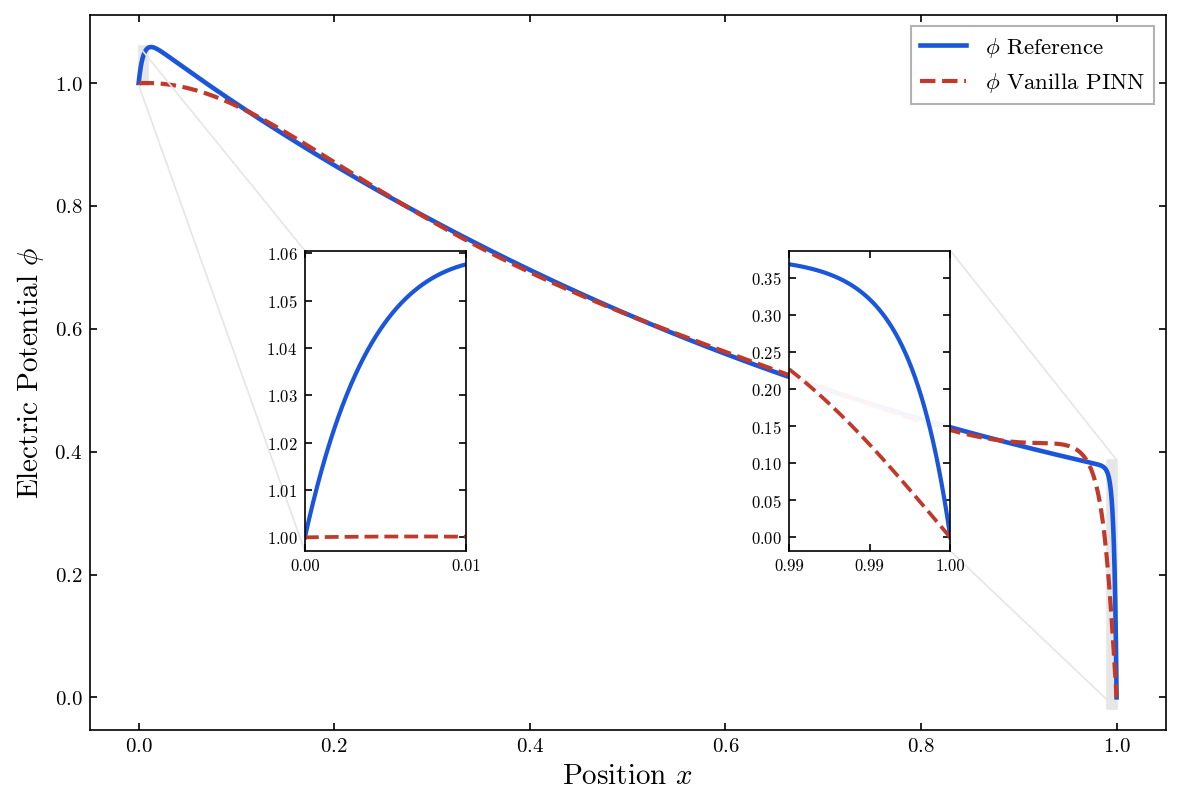

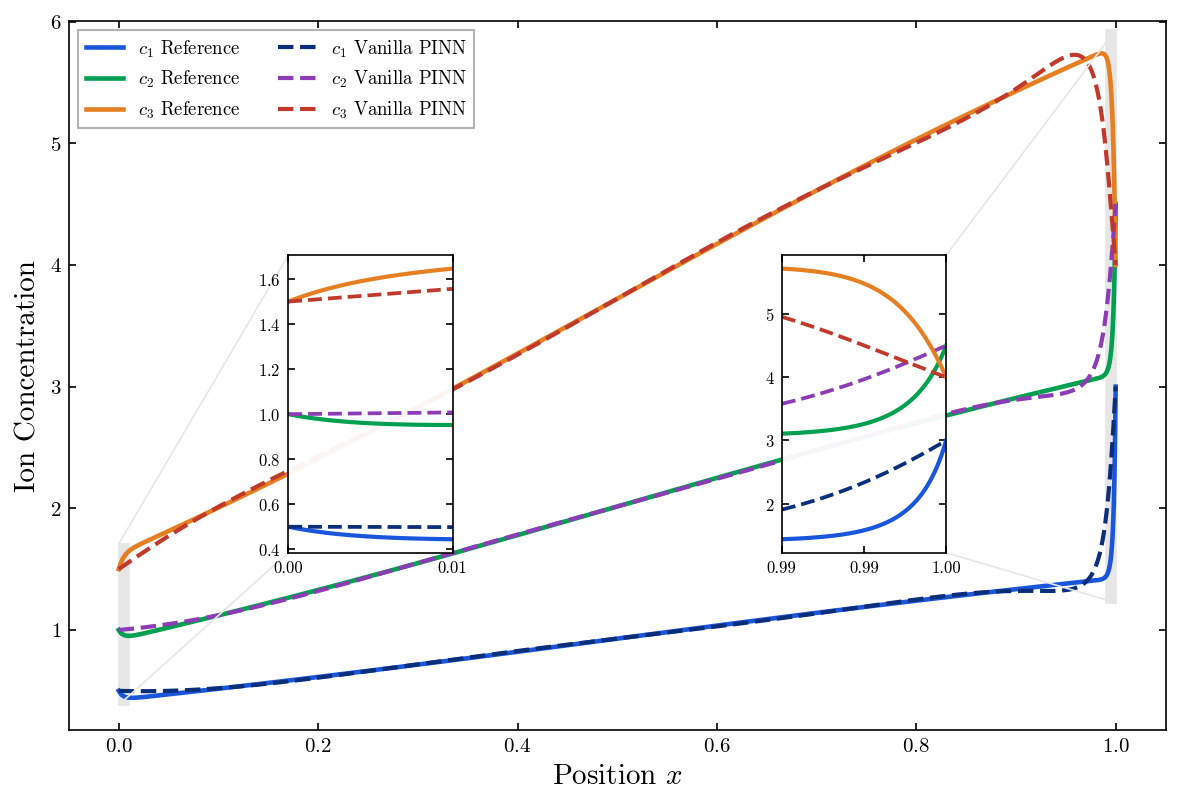

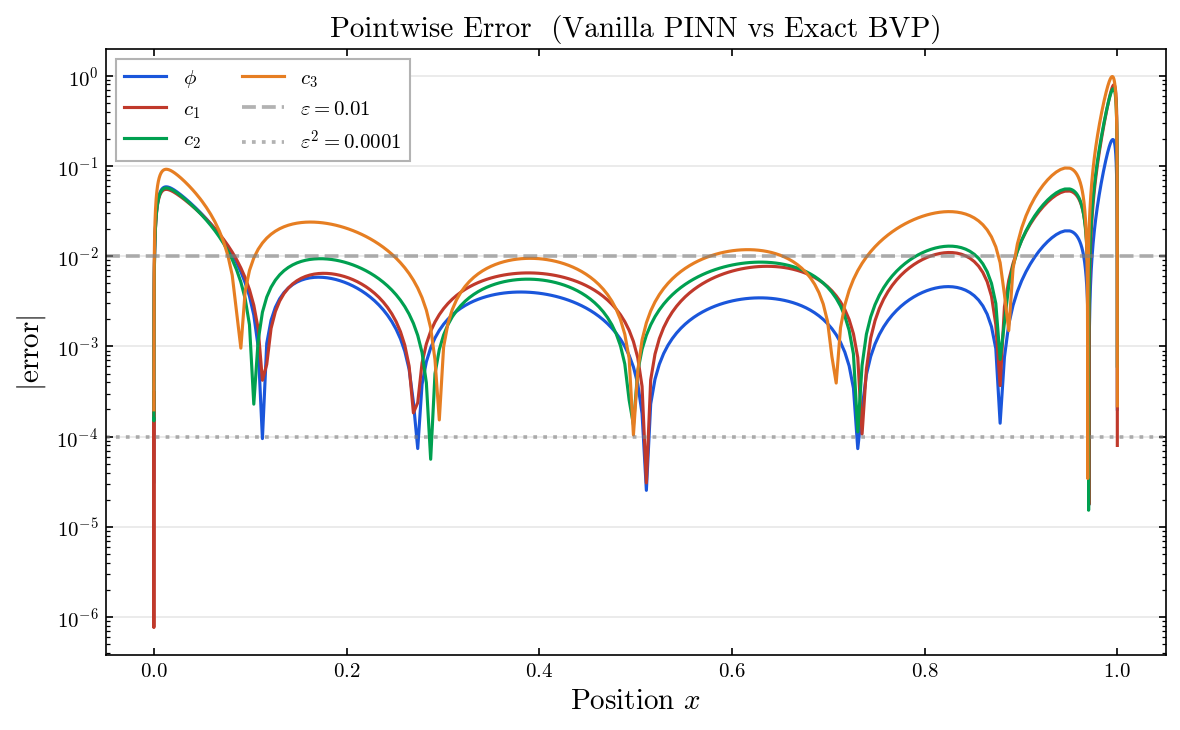

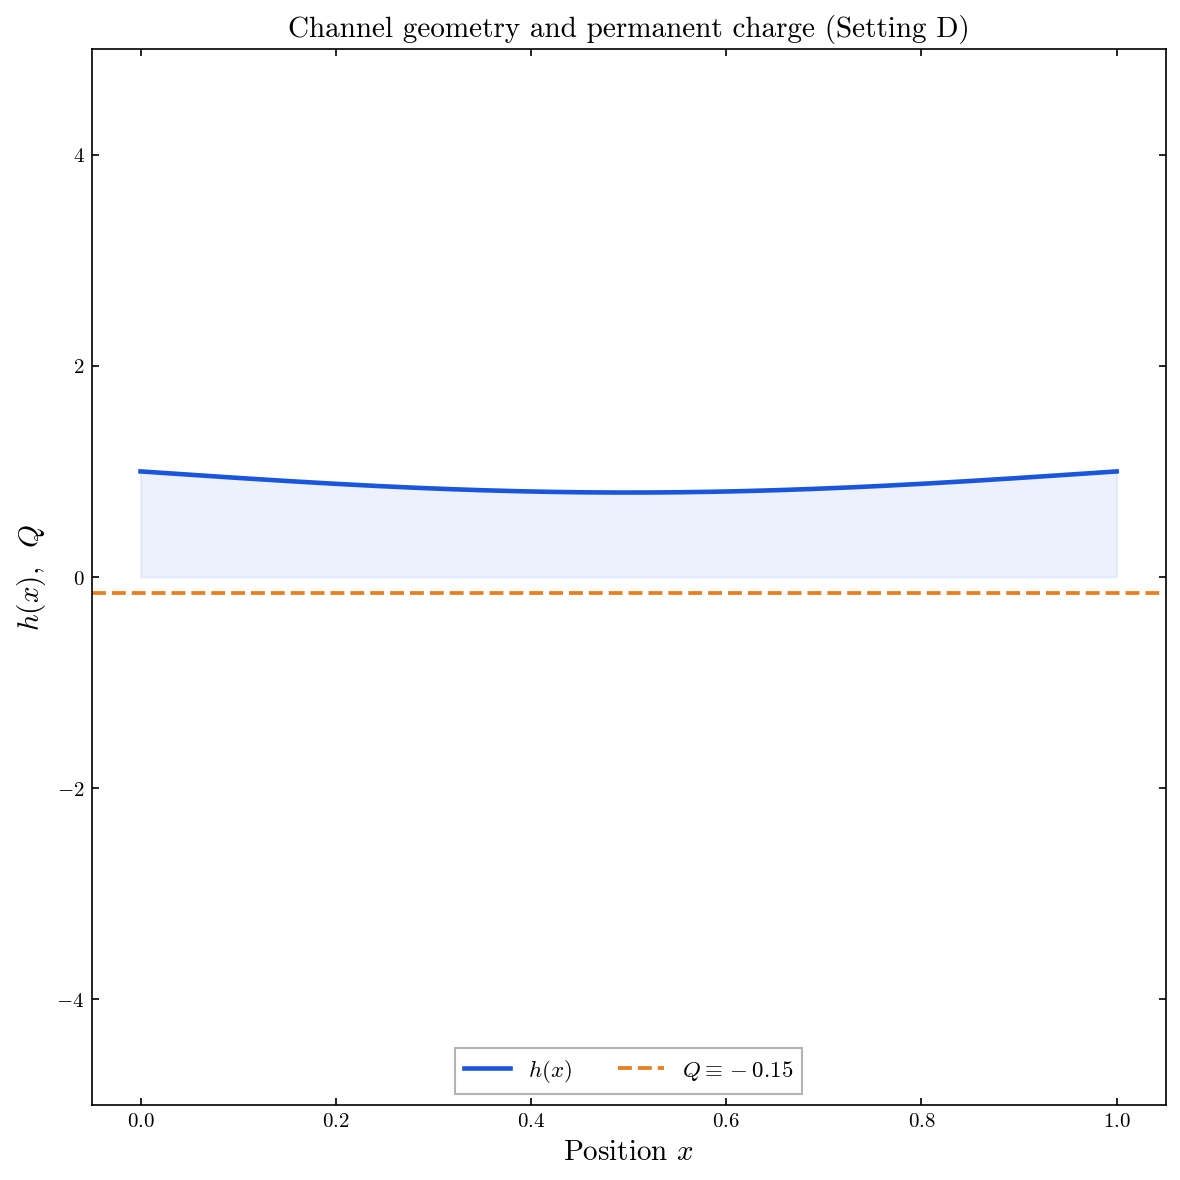

In [11]:
figs = plot_with_inset(x_eval, u_nn, u_ex, eps, METHOD_NAME)


## 11. 五次独立实验 (固定随机种子)


# ============================================================
#  五次独立实验 (固定随机种子, 报告 mean ± std)
# ============================================================
SEEDS = [0, 1, 2, 3, 4]
N_RUNS = len(SEEDS)

print('求解精确参考解 ...')
sol_exact = compute_exact_reference(eps, V, L, R, Q0)
grids = create_evaluation_grid(eps)
x_eval = grids['x']
u_ex, J_ex = exact_fields(sol_exact, x_eval)
print(f'  参考解节点数 {len(sol_exact.x)},  '
      f'J = ({J_ex[0]:+.5f}, {J_ex[1]:+.5f}, {J_ex[2]:+.5f}),  '
      f'I = Σα·J = {ALPHA_NP @ J_ex:+.5f}')

all_metrics, all_times = [], []
for run, sd in enumerate(SEEDS):
    print(f"\n{'='*56}")
    print(f'  Run {run+1}/{N_RUNS}   (seed = {sd})')
    print(f"{'='*56}")
    torch.manual_seed(sd)
    np.random.seed(sd)

    t0 = time.time()
    model_i = build_model()
    _ = train_model(model_i)
    elapsed = time.time() - t0
    all_times.append(elapsed)

    u_nn, J_nn = predict(model_i, x_eval)
    m = compute_unified_metrics(u_nn, u_ex, J_nn, J_ex, grids)
    all_metrics.append(m)
    print(f"  用时 {elapsed:.1f}s  |  全局相对 L²(φ) = "
          f"{m['phi']['global_rel_L2']:.4e}")

print(f'\n全部 {N_RUNS} 次实验完成!')

print(f"\n{'='*100}")
print(f'  {METHOD_NAME}   {N_RUNS} 次随机实验统计   (Setting D, ε = {eps})')
print(f"{'='*100}")
head = f"{'指标':<20s}" + ''.join(f"{lb:>19s}" for lb in VAR_LABELS)
print(head); print('-'*len(head))
for mk, ml in zip(METRIC_KEYS, METRIC_LABELS):
    row = ''
    for v in VAR_NAMES:
        vals = np.array([m[v][mk] for m in all_metrics])
        row += f'{vals.mean():>9.3e}±{vals.std():<9.3e}'
    print(f'{ml:<20s}{row}')
print('-'*len(head))
print(f'  训练用时: {np.mean(all_times):.1f} ± {np.std(all_times):.1f} s')
print(f"{'='*100}")
